# K-mer GO-split MLP with GO Frequency Filtering

This notebook follows the original `kmer_GO_split.ipynb` workflow, but adds one preprocessing step before GO namespace splitting:

> Remove GO terms with training frequency < 20.

Why this matters:
- GO labels are extremely sparse and long-tailed.
- Very rare GO terms are difficult to learn reliably.
- Filtering low-frequency labels can improve stability and make macro-F1 more meaningful.

Main workflow:
1. Load processed k-mer data
2. Remove GO terms with training frequency < 20
3. Split remaining GO terms into BPO / CCO / MFO
4. Train baseline and tuned namespace-specific MLP models
5. Compute micro-F1, macro-F1, and IA-weighted F1-max
6. Plot baseline vs tuned results

## Step 0. Imports and Settings

In [3]:
import os
import copy
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

from scipy.sparse import load_npz
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score

DATA_DIR = "data_processed_kmer_70"
TERMS_PATH = os.path.join("..", "cafa-5-protein-function-prediction", "Train", "train_terms.tsv")
IA_PATH = os.path.join("..", "cafa-5-protein-function-prediction", "IA.txt")

FREQ_THRESHOLD = 20
OUTPUT_DIR = "kmer_GO_split_freq20_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("DATA_DIR:", DATA_DIR)
print("FREQ_THRESHOLD:", FREQ_THRESHOLD)
print("OUTPUT_DIR:", OUTPUT_DIR)

Device: cpu
DATA_DIR: data_processed_kmer_70
FREQ_THRESHOLD: 20
OUTPUT_DIR: kmer_GO_split_freq20_outputs


## Step 1. Load Processed K-mer Data

### Why this step?
The k-mer preprocessing notebook already produced standardized k-mer vectors and sparse GO label matrices.

We load:
- `X_train.npy`, `X_val.npy`
- `Y_train.npz`, `Y_val.npz`
- `meta.pkl`, which contains the GO term order

In [6]:
X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
X_val = np.load(os.path.join(DATA_DIR, "X_val.npy"))
X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))

Y_train = load_npz(os.path.join(DATA_DIR, "Y_train.npz"))
Y_val = load_npz(os.path.join(DATA_DIR, "Y_val.npz"))
Y_test = load_npz(os.path.join(DATA_DIR, "Y_test.npz"))

with open(os.path.join(DATA_DIR, "meta.pkl"), "rb") as f:
    meta = pickle.load(f)

if isinstance(meta, dict) and "go_terms" in meta:
    go_terms = meta["go_terms"].tolist() if hasattr(meta["go_terms"], "tolist") else list(meta["go_terms"])
elif isinstance(meta, dict) and "mlb" in meta:
    go_terms = list(meta["mlb"].classes_)
elif hasattr(meta, "classes_"):
    go_terms = list(meta.classes_)
else:
    raise KeyError("Could not find GO term order in meta.pkl")

print("X_train:", X_train.shape, X_train.dtype)
print("X_val:  ", X_val.shape, X_val.dtype)
print("X_test:  ", X_test.shape, X_test.dtype)
print("Y_train:", Y_train.shape)
print("Y_val:  ", Y_val.shape)
print("Y_test:  ", Y_test.shape)
print("Number of GO terms:", len(go_terms))

assert Y_train.shape[1] == len(go_terms)
assert Y_val.shape[1] == len(go_terms)

X_train: (98397, 400) float32
X_val:   (21086, 400) float32
X_test:   (21086, 400) float32
Y_train: (98397, 31454)
Y_val:   (21086, 31454)
Y_test:   (21086, 31454)
Number of GO terms: 31454


## Step 2. Filter GO Terms with Training Frequency < 20

### Why this step?
The GO label space contains many rare labels.  
Labels with fewer than 20 positive training examples are unlikely to be learned reliably.

### Important design choice
The filtering threshold is computed using **training labels only** to avoid validation leakage.

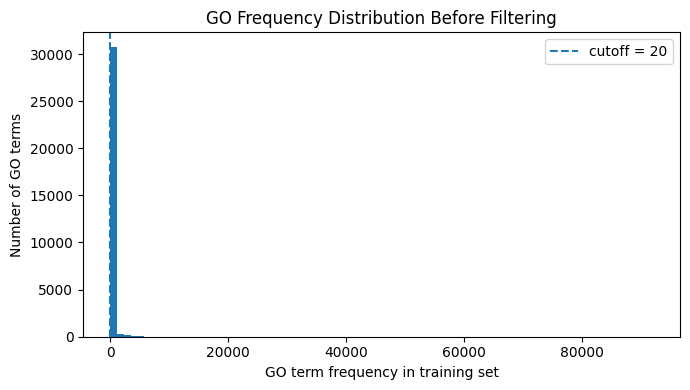

Original GO terms: 31454
Kept GO terms: 10617
Removed GO terms: 20837
Removed percentage: 66.24594646149933
Y_train_filtered: (98397, 10617)
Y_val_filtered:   (21086, 10617)
Y_test_filtered:   (21086, 10617)
Filtered GO terms: 10617


In [35]:
Y_full = scipy.sparse.vstack([Y_train, Y_val, Y_test])
label_counts = np.asarray(Y_full.sum(axis=0)).ravel().astype(np.float32)

plt.figure(figsize=(7, 4))
plt.hist(label_counts, bins=80)
plt.axvline(FREQ_THRESHOLD, linestyle="--", label=f"cutoff = {FREQ_THRESHOLD}")
plt.xlabel("GO term frequency in training set")
plt.ylabel("Number of GO terms")
plt.title("GO Frequency Distribution Before Filtering")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "go_frequency_distribution_before_filtering.png"), dpi=200, bbox_inches="tight")
plt.show()

keep_idx = np.where(label_counts >= FREQ_THRESHOLD)[0]
removed_idx = np.where(label_counts < FREQ_THRESHOLD)[0]

print("Original GO terms:", Y_train.shape[1])
print("Kept GO terms:", len(keep_idx))
print("Removed GO terms:", len(removed_idx))
print("Removed percentage:", 100 * len(removed_idx) / Y_train.shape[1])

# Filter target matrices
Y_train_filtered = Y_train[:, keep_idx]
Y_val_filtered = Y_val[:, keep_idx]
Y_test_filtered = Y_test[:, keep_idx]

# Update GO term order
go_terms_filtered = [go_terms[i] for i in keep_idx]

print("Y_train_filtered:", Y_train_filtered.shape)
print("Y_val_filtered:  ", Y_val_filtered.shape)
print("Y_test_filtered:  ", Y_test_filtered.shape)
print("Filtered GO terms:", len(go_terms_filtered))

## Step 3. Save Filtered Label Metadata

### Why this step?
Saving the filtered GO term list and index mapping makes the filtered experiment reproducible.

In [36]:
filter_metadata = {
    "freq_threshold": FREQ_THRESHOLD,
    "original_num_go_terms": int(Y_train.shape[1]),
    "kept_num_go_terms": int(len(keep_idx)),
    "removed_num_go_terms": int(len(removed_idx)),
    "keep_idx": keep_idx.tolist(),
    "removed_idx": removed_idx.tolist(),
    "go_terms_filtered": go_terms_filtered,
}

with open(os.path.join(OUTPUT_DIR, "filter_metadata.json"), "w") as f:
    json.dump(filter_metadata, f, indent=2)

print("Saved filter metadata to:", os.path.join(OUTPUT_DIR, "filter_metadata.json"))

Saved filter metadata to: kmer_GO_split_freq20_outputs/filter_metadata.json


## Step 4. Load GO Namespace Mapping

### Why this step?
After filtering, we need to rebuild BPO / CCO / MFO indices using the filtered GO term order.

In [10]:
terms_df = pd.read_csv(TERMS_PATH, sep="\t")

go_to_aspect = (
    terms_df[["term", "aspect"]]
    .drop_duplicates()
    .set_index("term")["aspect"]
    .to_dict()
)

bpo_idx = [i for i, go in enumerate(go_terms_filtered) if go_to_aspect.get(go) == "BPO"]
cco_idx = [i for i, go in enumerate(go_terms_filtered) if go_to_aspect.get(go) == "CCO"]
mfo_idx = [i for i, go in enumerate(go_terms_filtered) if go_to_aspect.get(go) == "MFO"]

print("Filtered total GO terms:", len(go_terms_filtered))
print("BPO labels:", len(bpo_idx))
print("CCO labels:", len(cco_idx))
print("MFO labels:", len(mfo_idx))
print("Check total:", len(bpo_idx) + len(cco_idx) + len(mfo_idx))

namespace_go_terms = {
    "BPO": [go_terms_filtered[i] for i in bpo_idx],
    "CCO": [go_terms_filtered[i] for i in cco_idx],
    "MFO": [go_terms_filtered[i] for i in mfo_idx],
}

Filtered total GO terms: 10617
BPO labels: 7983
CCO labels: 1065
MFO labels: 1569
Check total: 10617


## Step 5. Split Filtered Labels by Namespace

In [37]:
Y_train_BPO = Y_train_filtered[:, bpo_idx]
Y_val_BPO   = Y_val_filtered[:, bpo_idx]
Y_test_BPO = Y_test_filtered[:, bpo_idx]

Y_train_CCO = Y_train_filtered[:, cco_idx]
Y_val_CCO   = Y_val_filtered[:, cco_idx]
Y_test_CCO = Y_test_filtered[:, cco_idx]

Y_train_MFO = Y_train_filtered[:, mfo_idx]
Y_val_MFO   = Y_val_filtered[:, mfo_idx]
Y_test_MFO = Y_test_filtered[:, mfo_idx]

print("Y_train_BPO:", Y_train_BPO.shape, "Y_val_BPO:", Y_val_BPO.shape)
print("Y_train_CCO:", Y_train_CCO.shape, "Y_val_CCO:", Y_val_CCO.shape)
print("Y_train_MFO:", Y_train_MFO.shape, "Y_val_MFO:", Y_val_MFO.shape)

Y_train_BPO: (98397, 7983) Y_val_BPO: (21086, 7983)
Y_train_CCO: (98397, 1065) Y_val_CCO: (21086, 1065)
Y_train_MFO: (98397, 1569) Y_val_MFO: (21086, 1569)


## Step 6. Define Dataset, Model, and Training Helpers

In [12]:
class ProteinKmerDataset(Dataset):
    def __init__(self, X, Y_sparse):
        self.X = X.astype(np.float32)
        self.Y = Y_sparse.tocsr()
        self.n_labels = self.Y.shape[1]

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])

        start = self.Y.indptr[idx]
        end = self.Y.indptr[idx + 1]
        pos_idx = self.Y.indices[start:end]

        y = torch.zeros(self.n_labels, dtype=torch.float32)
        y[pos_idx] = 1.0

        return x, y


class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden1=512, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, output_dim)
        )

    def forward(self, x):
        return self.net(x)


def build_dataloaders(train_dataset, val_dataset, batch_size):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader


def build_model(config, input_dim, output_dim, device):
    return MLP(
        input_dim=input_dim,
        output_dim=output_dim,
        hidden1=config["hidden1"],
        #hidden2=config["hidden2"],
        dropout=config["dropout"]
    ).to(device)


def build_optimizer(model, config):
    return optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )

In [13]:
def build_namespace_criterion(Y_train_namespace, device):
    label_counts_ns = np.asarray(Y_train_namespace.sum(axis=0)).ravel().astype(np.float32)
    n_train = Y_train_namespace.shape[0]

    pos_weight = (n_train - label_counts_ns) / (label_counts_ns + 1e-6)
    pos_weight = np.clip(pos_weight, 1.0, 100.0)

    pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32, device=device)
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        Y_batch = Y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, Y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        Y_batch = Y_batch.to(device, non_blocking=True)

        logits = model(X_batch)
        loss = criterion(logits, Y_batch)

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_probs = []
    all_targets = []

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_targets.append(Y_batch.numpy())

    return np.vstack(all_probs), np.vstack(all_targets)


def threshold_sweep(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.95, 0.1)

    records = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(np.int8)

        micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
        macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

        records.append({
            "threshold": float(t),
            "micro_f1": float(micro),
            "macro_f1": float(macro),
        })

    best_micro_row = max(records, key=lambda x: x["micro_f1"])
    best_macro_row = max(records, key=lambda x: x["macro_f1"])

    return records, best_micro_row, best_macro_row

In [14]:
def train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=5,
    patience=3,
    save_path=None
):
    best_val_loss = float("inf")
    best_state_dict = None
    epochs_no_improve = 0

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1:02d}/{num_epochs} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0

            if save_path is not None:
                torch.save(best_state_dict, save_path)
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, train_losses, val_losses, best_val_loss


def run_experiment(
    config,
    train_dataset,
    val_dataset,
    input_dim,
    output_dim,
    criterion,
    device,
    run_threshold_sweep=True
):
    train_loader, val_loader = build_dataloaders(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        batch_size=config["batch_size"]
    )

    model = build_model(config, input_dim, output_dim, device)
    optimizer = build_optimizer(model, config)

    save_path = os.path.join(OUTPUT_DIR, f"{config['save_prefix']}.pt")

    model, train_losses, val_losses, best_val_loss = train_with_early_stopping(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=config["num_epochs"],
        patience=config["patience"],
        save_path=save_path
    )

    result = {
        "config": config.copy(),
        "model": model,
        "model_path": save_path,
        "best_val_loss": best_val_loss,
        "train_losses": train_losses,
        "val_losses": val_losses,
    }

    if run_threshold_sweep:
        val_probs, val_targets = get_predictions(model, val_loader, device)
        records, best_micro_row, best_macro_row = threshold_sweep(val_targets, val_probs)

        result["threshold_records"] = records
        result["best_micro_row"] = best_micro_row
        result["best_macro_row"] = best_macro_row

    return result

## Step 7. Build Namespace-Specific Datasets and Loss Functions

In [15]:
train_dataset_BPO = ProteinKmerDataset(X_train, Y_train_BPO)
val_dataset_BPO   = ProteinKmerDataset(X_val, Y_val_BPO)

train_dataset_CCO = ProteinKmerDataset(X_train, Y_train_CCO)
val_dataset_CCO   = ProteinKmerDataset(X_val, Y_val_CCO)

train_dataset_MFO = ProteinKmerDataset(X_train, Y_train_MFO)
val_dataset_MFO   = ProteinKmerDataset(X_val, Y_val_MFO)

criterion_BPO = build_namespace_criterion(Y_train_BPO, device)
criterion_CCO = build_namespace_criterion(Y_train_CCO, device)
criterion_MFO = build_namespace_criterion(Y_train_MFO, device)

print("BPO dataset sizes:", len(train_dataset_BPO), len(val_dataset_BPO))
print("CCO dataset sizes:", len(train_dataset_CCO), len(val_dataset_CCO))
print("MFO dataset sizes:", len(train_dataset_MFO), len(val_dataset_MFO))
print("Built namespace-specific criteria.")

BPO dataset sizes: 98397 21086
CCO dataset sizes: 98397 21086
MFO dataset sizes: 98397 21086
Built namespace-specific criteria.


## Step 8. Define Baseline and Tuned Configurations

### Note
You can edit these configs directly if you want to test different settings.

In [16]:
BASELINE_NAMESPACE_CONFIG = {
    "hidden1": 512,
    #"hidden2": 256,
    "dropout": 0.3,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "batch_size": 64,
    "num_epochs": 5,
    "patience": 3,
    "save_prefix": "kmer_freq20_baseline_namespace"
}

TUNED_NAMESPACE_CONFIG = {
    "hidden1": 256,
    #"hidden2": 512,
    "dropout": 0.3,
    "learning_rate": 1e-3,
    "weight_decay": 0.0,
    "batch_size": 64,
    "num_epochs": 5,
    "patience": 3,
    "save_prefix": "kmer_freq20_tuned_namespace"
}

print("BASELINE_NAMESPACE_CONFIG:")
print(BASELINE_NAMESPACE_CONFIG)
print()
print("TUNED_NAMESPACE_CONFIG:")
print(TUNED_NAMESPACE_CONFIG)

BASELINE_NAMESPACE_CONFIG:
{'hidden1': 512, 'dropout': 0.3, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'batch_size': 64, 'num_epochs': 5, 'patience': 3, 'save_prefix': 'kmer_freq20_baseline_namespace'}

TUNED_NAMESPACE_CONFIG:
{'hidden1': 256, 'dropout': 0.3, 'learning_rate': 0.001, 'weight_decay': 0.0, 'batch_size': 64, 'num_epochs': 5, 'patience': 3, 'save_prefix': 'kmer_freq20_tuned_namespace'}


## Step 9. Train Baseline Models for BPO / CCO / MFO

In [17]:
# Baseline BPO
config_BPO_base = BASELINE_NAMESPACE_CONFIG.copy()
config_BPO_base["save_prefix"] = "kmer_freq20_BPO_baseline"

result_BPO_base = run_experiment(
    config=config_BPO_base,
    train_dataset=train_dataset_BPO,
    val_dataset=val_dataset_BPO,
    input_dim=X_train.shape[1],
    output_dim=Y_train_BPO.shape[1],
    criterion=criterion_BPO,
    device=device,
    run_threshold_sweep=True
)

# Baseline CCO
config_CCO_base = BASELINE_NAMESPACE_CONFIG.copy()
config_CCO_base["save_prefix"] = "kmer_freq20_CCO_baseline"

result_CCO_base = run_experiment(
    config=config_CCO_base,
    train_dataset=train_dataset_CCO,
    val_dataset=val_dataset_CCO,
    input_dim=X_train.shape[1],
    output_dim=Y_train_CCO.shape[1],
    criterion=criterion_CCO,
    device=device,
    run_threshold_sweep=True
)

# Baseline MFO
config_MFO_base = BASELINE_NAMESPACE_CONFIG.copy()
config_MFO_base["save_prefix"] = "kmer_freq20_MFO_baseline"

result_MFO_base = run_experiment(
    config=config_MFO_base,
    train_dataset=train_dataset_MFO,
    val_dataset=val_dataset_MFO,
    input_dim=X_train.shape[1],
    output_dim=Y_train_MFO.shape[1],
    criterion=criterion_MFO,
    device=device,
    run_threshold_sweep=True
)

Epoch 01/5 | train_loss=0.316544 | val_loss=0.290266
Epoch 02/5 | train_loss=0.276001 | val_loss=0.282694
Epoch 03/5 | train_loss=0.257823 | val_loss=0.279294
Epoch 04/5 | train_loss=0.245008 | val_loss=0.279643
Epoch 05/5 | train_loss=0.235812 | val_loss=0.279263
Epoch 01/5 | train_loss=0.364930 | val_loss=0.328989
Epoch 02/5 | train_loss=0.297266 | val_loss=0.318610
Epoch 03/5 | train_loss=0.261571 | val_loss=0.318635
Epoch 04/5 | train_loss=0.238753 | val_loss=0.326280
Epoch 05/5 | train_loss=0.223422 | val_loss=0.336740
Early stopping triggered at epoch 5
Epoch 01/5 | train_loss=0.258339 | val_loss=0.218017
Epoch 02/5 | train_loss=0.196926 | val_loss=0.205681
Epoch 03/5 | train_loss=0.169744 | val_loss=0.207954
Epoch 04/5 | train_loss=0.152845 | val_loss=0.211970
Epoch 05/5 | train_loss=0.141777 | val_loss=0.215610
Early stopping triggered at epoch 5


## Step 10. Train Tuned Models for BPO / CCO / MFO

In [18]:
# Tuned BPO
config_BPO_tuned = TUNED_NAMESPACE_CONFIG.copy()
config_BPO_tuned["save_prefix"] = "kmer_freq20_BPO_tuned"

result_BPO_tuned = run_experiment(
    config=config_BPO_tuned,
    train_dataset=train_dataset_BPO,
    val_dataset=val_dataset_BPO,
    input_dim=X_train.shape[1],
    output_dim=Y_train_BPO.shape[1],
    criterion=criterion_BPO,
    device=device,
    run_threshold_sweep=True
)

# Tuned CCO
config_CCO_tuned = TUNED_NAMESPACE_CONFIG.copy()
config_CCO_tuned["save_prefix"] = "kmer_freq20_CCO_tuned"

result_CCO_tuned = run_experiment(
    config=config_CCO_tuned,
    train_dataset=train_dataset_CCO,
    val_dataset=val_dataset_CCO,
    input_dim=X_train.shape[1],
    output_dim=Y_train_CCO.shape[1],
    criterion=criterion_CCO,
    device=device,
    run_threshold_sweep=True
)

# Tuned MFO
config_MFO_tuned = TUNED_NAMESPACE_CONFIG.copy()
config_MFO_tuned["save_prefix"] = "kmer_freq20_MFO_tuned"

result_MFO_tuned = run_experiment(
    config=config_MFO_tuned,
    train_dataset=train_dataset_MFO,
    val_dataset=val_dataset_MFO,
    input_dim=X_train.shape[1],
    output_dim=Y_train_MFO.shape[1],
    criterion=criterion_MFO,
    device=device,
    run_threshold_sweep=True
)

Epoch 01/5 | train_loss=0.325081 | val_loss=0.296935
Epoch 02/5 | train_loss=0.282591 | val_loss=0.286514
Epoch 03/5 | train_loss=0.262064 | val_loss=0.283331
Epoch 04/5 | train_loss=0.246266 | val_loss=0.286489
Epoch 05/5 | train_loss=0.234835 | val_loss=0.289906
Epoch 01/5 | train_loss=0.372740 | val_loss=0.333652
Epoch 02/5 | train_loss=0.310393 | val_loss=0.320722
Epoch 03/5 | train_loss=0.281825 | val_loss=0.318093
Epoch 04/5 | train_loss=0.261916 | val_loss=0.325589
Epoch 05/5 | train_loss=0.247290 | val_loss=0.330985
Epoch 01/5 | train_loss=0.266523 | val_loss=0.223875
Epoch 02/5 | train_loss=0.209586 | val_loss=0.211798
Epoch 03/5 | train_loss=0.185196 | val_loss=0.209611
Epoch 04/5 | train_loss=0.168657 | val_loss=0.213520
Epoch 05/5 | train_loss=0.157842 | val_loss=0.219017


In [19]:
def plot_loss_by_namespace(results_dict, model_name="K-mer MLP"):
    namespaces = ["BPO", "CCO", "MFO"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

    for ax, ns in zip(axes, namespaces):
        result = results_dict[ns]

        train_losses = result["train_losses"]
        val_losses = result["val_losses"]
        epochs = np.arange(1, len(train_losses) + 1)

        ax.plot(epochs, train_losses, marker="o", label="Train loss")
        ax.plot(epochs, val_losses, marker="o", label="Val loss")

        best_epoch = int(np.argmin(val_losses)) + 1
        best_val = min(val_losses)

        ax.axvline(best_epoch, linestyle="--", alpha=0.6)
        ax.annotate(
            f"checkpoint @ ep {best_epoch}\nval loss = {best_val:.4f}",
            xy=(best_epoch, best_val),
            xytext=(best_epoch + 0.2, best_val + 0.002),
            arrowprops=dict(arrowstyle="->", alpha=0.6),
            fontsize=9
        )

        ax.set_title(f"{ns} — {model_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("BCE loss")
        ax.set_xticks(epochs)
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, f"{model_name.replace(' ', '_')}_loss_by_namespace.png"),
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

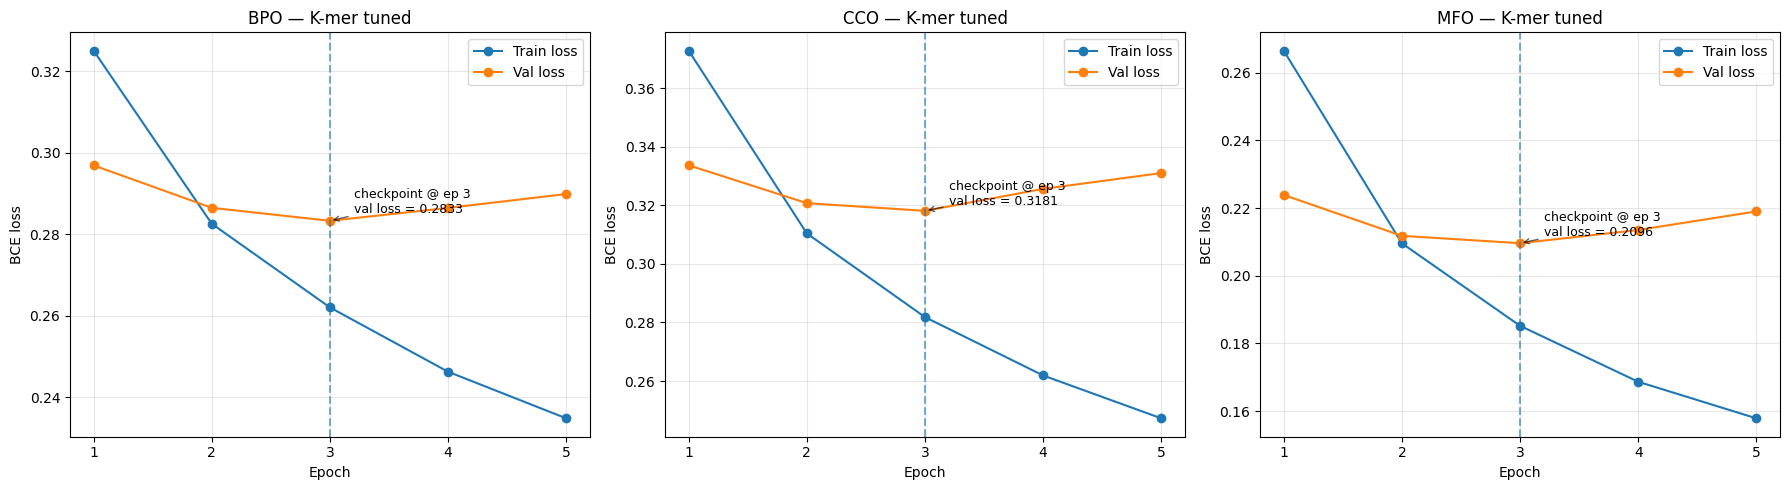

In [20]:
tuned_results = {
    "BPO": result_BPO_tuned,
    "CCO": result_CCO_tuned,
    "MFO": result_MFO_tuned,
}

plot_loss_by_namespace(tuned_results, model_name="K-mer tuned")

## Step 11. Load IA Weights and Align to Filtered Namespaces

### Why this step?
F1-max uses GO-specific information accretion weights.  
After filtering, the IA vector must be aligned to the **filtered GO term order**.

In [21]:
def load_ia_weights(path):
    ia_map = {}
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            go_term, weight = line.split()
            ia_map[go_term] = float(weight)
    return ia_map


ia_map = load_ia_weights(IA_PATH)

ia_weights_filtered = np.array([ia_map.get(go, 0.0) for go in go_terms_filtered], dtype=np.float32)

ia_weights_BPO = ia_weights_filtered[bpo_idx]
ia_weights_CCO = ia_weights_filtered[cco_idx]
ia_weights_MFO = ia_weights_filtered[mfo_idx]

print("IA weights filtered:", ia_weights_filtered.shape)
print("IA weights BPO:", ia_weights_BPO.shape)
print("IA weights CCO:", ia_weights_CCO.shape)
print("IA weights MFO:", ia_weights_MFO.shape)

IA weights filtered: (10617,)
IA weights BPO: (7983,)
IA weights CCO: (1065,)
IA weights MFO: (1569,)


## Step 12. Compute IA-weighted F1-max

In [22]:
def weighted_fmax_from_probs(y_true, y_prob, ia_weights, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.95, 0.1)

    eps = 1e-12
    records = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(np.int8)

        tp = ((y_true == 1) & (y_pred == 1)).sum(axis=0).astype(np.float64)
        fp = ((y_true == 0) & (y_pred == 1)).sum(axis=0).astype(np.float64)
        fn = ((y_true == 1) & (y_pred == 0)).sum(axis=0).astype(np.float64)

        weighted_tp = (tp * ia_weights).sum()
        weighted_fp = (fp * ia_weights).sum()
        weighted_fn = (fn * ia_weights).sum()

        weighted_precision = weighted_tp / (weighted_tp + weighted_fp + eps)
        weighted_recall = weighted_tp / (weighted_tp + weighted_fn + eps)
        weighted_f1 = 2 * weighted_precision * weighted_recall / (weighted_precision + weighted_recall + eps)

        records.append({
            "threshold": float(t),
            "weighted_precision": float(weighted_precision),
            "weighted_recall": float(weighted_recall),
            "weighted_f1": float(weighted_f1),
        })

    best_row = max(records, key=lambda x: x["weighted_f1"])
    return records, best_row

## Step 13. Collect Predictions and Compute Final Metrics

In [23]:
_, val_loader_BPO = build_dataloaders(train_dataset_BPO, val_dataset_BPO, BASELINE_NAMESPACE_CONFIG["batch_size"])
_, val_loader_CCO = build_dataloaders(train_dataset_CCO, val_dataset_CCO, BASELINE_NAMESPACE_CONFIG["batch_size"])
_, val_loader_MFO = build_dataloaders(train_dataset_MFO, val_dataset_MFO, BASELINE_NAMESPACE_CONFIG["batch_size"])

baseline_probs_BPO, baseline_targets_BPO = get_predictions(result_BPO_base["model"], val_loader_BPO, device)
tuned_probs_BPO, tuned_targets_BPO = get_predictions(result_BPO_tuned["model"], val_loader_BPO, device)

baseline_probs_CCO, baseline_targets_CCO = get_predictions(result_CCO_base["model"], val_loader_CCO, device)
tuned_probs_CCO, tuned_targets_CCO = get_predictions(result_CCO_tuned["model"], val_loader_CCO, device)

baseline_probs_MFO, baseline_targets_MFO = get_predictions(result_MFO_base["model"], val_loader_MFO, device)
tuned_probs_MFO, tuned_targets_MFO = get_predictions(result_MFO_tuned["model"], val_loader_MFO, device)

thresholds = np.arange(0.05, 0.95, 0.1)

baseline_fmax_records_BPO, baseline_best_fmax_BPO = weighted_fmax_from_probs(
    baseline_targets_BPO, baseline_probs_BPO, ia_weights_BPO, thresholds=thresholds
)
tuned_fmax_records_BPO, tuned_best_fmax_BPO = weighted_fmax_from_probs(
    tuned_targets_BPO, tuned_probs_BPO, ia_weights_BPO, thresholds=thresholds
)

baseline_fmax_records_CCO, baseline_best_fmax_CCO = weighted_fmax_from_probs(
    baseline_targets_CCO, baseline_probs_CCO, ia_weights_CCO, thresholds=thresholds
)
tuned_fmax_records_CCO, tuned_best_fmax_CCO = weighted_fmax_from_probs(
    tuned_targets_CCO, tuned_probs_CCO, ia_weights_CCO, thresholds=thresholds
)

baseline_fmax_records_MFO, baseline_best_fmax_MFO = weighted_fmax_from_probs(
    baseline_targets_MFO, baseline_probs_MFO, ia_weights_MFO, thresholds=thresholds
)
tuned_fmax_records_MFO, tuned_best_fmax_MFO = weighted_fmax_from_probs(
    tuned_targets_MFO, tuned_probs_MFO, ia_weights_MFO, thresholds=thresholds
)

In [24]:
comparison_all_df = pd.DataFrame([
    {
        "namespace": "BPO",
        "model": "baseline",
        "micro_f1": result_BPO_base["best_micro_row"]["micro_f1"],
        "macro_f1": result_BPO_base["best_macro_row"]["macro_f1"],
        "f1_max": baseline_best_fmax_BPO["weighted_f1"],
        "best_val_loss": result_BPO_base["best_val_loss"],
    },
    {
        "namespace": "BPO",
        "model": "tuned",
        "micro_f1": result_BPO_tuned["best_micro_row"]["micro_f1"],
        "macro_f1": result_BPO_tuned["best_macro_row"]["macro_f1"],
        "f1_max": tuned_best_fmax_BPO["weighted_f1"],
        "best_val_loss": result_BPO_tuned["best_val_loss"],
    },
    {
        "namespace": "CCO",
        "model": "baseline",
        "micro_f1": result_CCO_base["best_micro_row"]["micro_f1"],
        "macro_f1": result_CCO_base["best_macro_row"]["macro_f1"],
        "f1_max": baseline_best_fmax_CCO["weighted_f1"],
        "best_val_loss": result_CCO_base["best_val_loss"],
    },
    {
        "namespace": "CCO",
        "model": "tuned",
        "micro_f1": result_CCO_tuned["best_micro_row"]["micro_f1"],
        "macro_f1": result_CCO_tuned["best_macro_row"]["macro_f1"],
        "f1_max": tuned_best_fmax_CCO["weighted_f1"],
        "best_val_loss": result_CCO_tuned["best_val_loss"],
    },
    {
        "namespace": "MFO",
        "model": "baseline",
        "micro_f1": result_MFO_base["best_micro_row"]["micro_f1"],
        "macro_f1": result_MFO_base["best_macro_row"]["macro_f1"],
        "f1_max": baseline_best_fmax_MFO["weighted_f1"],
        "best_val_loss": result_MFO_base["best_val_loss"],
    },
    {
        "namespace": "MFO",
        "model": "tuned",
        "micro_f1": result_MFO_tuned["best_micro_row"]["micro_f1"],
        "macro_f1": result_MFO_tuned["best_macro_row"]["macro_f1"],
        "f1_max": tuned_best_fmax_MFO["weighted_f1"],
        "best_val_loss": result_MFO_tuned["best_val_loss"],
    },
])

display(comparison_all_df)

comparison_all_df.to_csv(os.path.join(OUTPUT_DIR, "kmer_70_metrics.csv"), index=False)
print("Saved comparison table to:", os.path.join(OUTPUT_DIR, "kmer_baseline_tuned_metrics.csv"))

,namespace,model,micro_f1,macro_f1,f1_max,best_val_loss
0,BPO,baseline,0.119432,0.079289,0.104456,0.279263
1,BPO,tuned,0.120219,0.059752,0.102033,0.283331
2,CCO,baseline,0.196967,0.099275,0.129393,0.318610
3,CCO,tuned,0.200331,0.100310,0.133875,0.318093
4,MFO,baseline,0.154337,0.151635,0.147398,0.205681
5,MFO,tuned,0.163335,0.147531,0.157715,0.209611


Saved comparison table to: kmer_GO_split_freq20_outputs/kmer_freq20_baseline_tuned_metrics.csv


## Step 14. Plot Baseline vs Tuned Across Metrics

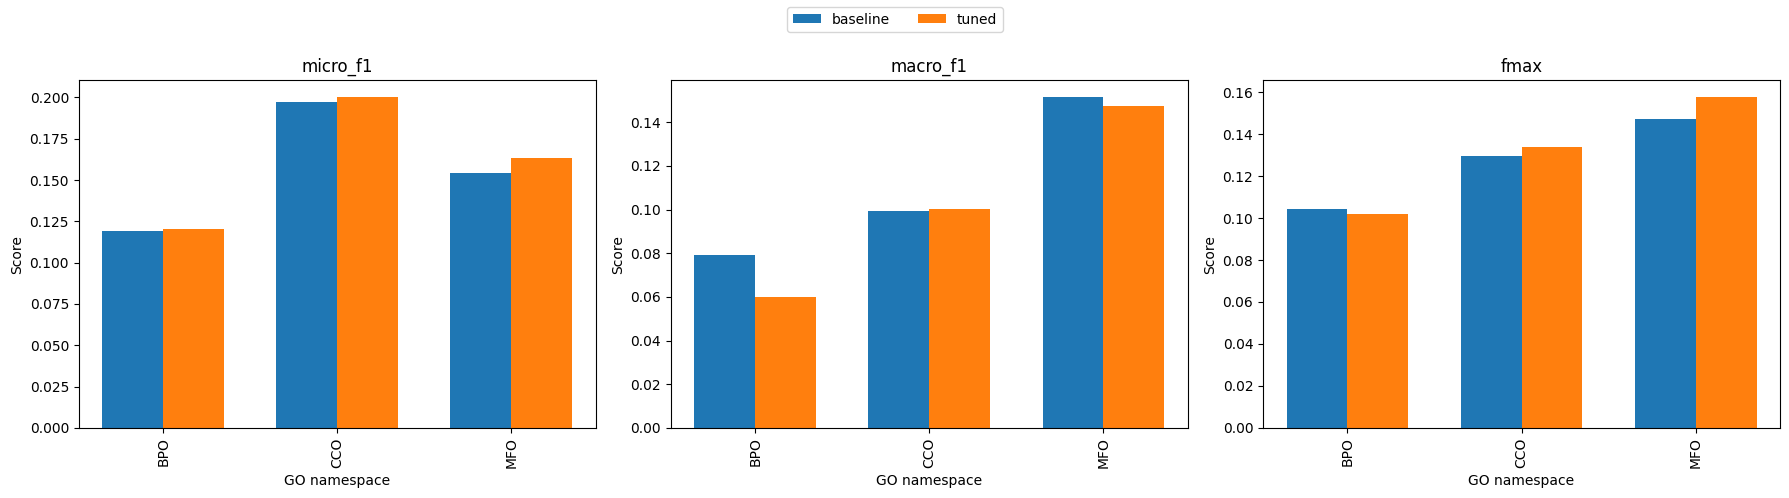

In [25]:
def plot_namespace_metric_panels(comparison_all_df):
    namespaces = ["BPO", "CCO", "MFO"]
    metric_specs = [
        ("micro_f1", "micro_f1"),
        ("macro_f1", "macro_f1"),
        ("f1_max", "fmax"),
    ]

    x = np.arange(len(namespaces))
    width = 0.35

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (metric_col, title) in zip(axes, metric_specs):
        baseline_scores = []
        tuned_scores = []

        for ns in namespaces:
            subset = comparison_all_df[comparison_all_df["namespace"] == ns]
            baseline_row = subset[subset["model"] == "baseline"].iloc[0]
            tuned_row = subset[subset["model"] == "tuned"].iloc[0]

            baseline_scores.append(baseline_row[metric_col])
            tuned_scores.append(tuned_row[metric_col])

        ax.bar(x - width/2, baseline_scores, width=width, label="baseline")
        ax.bar(x + width/2, tuned_scores, width=width, label="tuned")

        ax.set_xticks(x)
        ax.set_xticklabels(namespaces, rotation=90)
        ax.set_xlabel("GO namespace")
        ax.set_ylabel("Score")
        ax.set_title(title)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig(os.path.join(OUTPUT_DIR, "kmer_freq20_baseline_vs_tuned_metrics.png"), dpi=200, bbox_inches="tight")
    plt.show()


plot_namespace_metric_panels(comparison_all_df)

## Step 15. Optional: Compare Filtered Label Space to Original Label Space

### Why this step?
This summarizes how much the label filtering reduced the output dimension.

,stage,num_go_terms
0,Original,31454
1,Filtered >= 20,10617


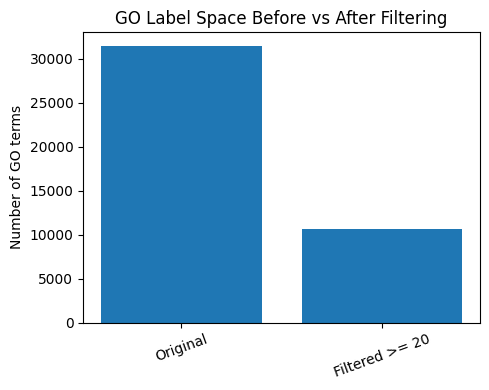

In [26]:
filter_summary_df = pd.DataFrame([
    {"stage": "Original", "num_go_terms": int(Y_train.shape[1])},
    {"stage": f"Filtered >= {FREQ_THRESHOLD}", "num_go_terms": int(Y_train_filtered.shape[1])},
])

display(filter_summary_df)

plt.figure(figsize=(5, 4))
plt.bar(filter_summary_df["stage"], filter_summary_df["num_go_terms"])
plt.ylabel("Number of GO terms")
plt.title("GO Label Space Before vs After Filtering")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "go_label_space_before_after_filtering.png"), dpi=200, bbox_inches="tight")
plt.show()

## Summary

This notebook adds a label-frequency filtering step before GO namespace splitting.

Key design choices:
- GO frequency is computed using `Y_train` only.
- GO terms with fewer than 20 positive training examples are removed.
- The filtered label space is then split into BPO / CCO / MFO.
- Baseline and tuned MLP models are trained separately for each namespace.
- Evaluation uses micro-F1, macro-F1, and IA-weighted F1-max.

This allows us to compare whether label pruning improves stability and performance relative to the full GO-label experiment.

In [39]:
test_dataset_BPO = ProteinKmerDataset(X_test, Y_test_BPO)
test_dataset_CCO = ProteinKmerDataset(X_test, Y_test_CCO)
test_dataset_MFO = ProteinKmerDataset(X_test, Y_test_MFO)

batch_size=TUNED_NAMESPACE_CONFIG["batch_size"]

test_loader_BPO = DataLoader(test_dataset_BPO, batch_size=batch_size, shuffle=False)
test_loader_CCO = DataLoader(test_dataset_CCO, batch_size=batch_size, shuffle=False)
test_loader_MFO = DataLoader(test_dataset_MFO, batch_size=batch_size, shuffle=False)

In [42]:
import numpy as np

def weighted_fmax_from_probs(y_true, y_prob, ia_weights, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)

    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    ia_weights = np.asarray(ia_weights)

    best = {
        "threshold": None,
        "ia_weighted_fmax": -1,
        "ia_weighted_precision": None,
        "ia_weighted_recall": None,
    }

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)

        tp = ((y_pred == 1) & (y_true == 1)) * ia_weights
        fp = ((y_pred == 1) & (y_true == 0)) * ia_weights
        fn = ((y_pred == 0) & (y_true == 1)) * ia_weights

        TP = tp.sum()
        FP = fp.sum()
        FN = fn.sum()

        precision = TP / (TP + FP + 1e-12)
        recall = TP / (TP + FN + 1e-12)
        f1 = 2 * precision * recall / (precision + recall + 1e-12)

        if f1 > best["ia_weighted_fmax"]:
            best = {
                "threshold": float(t),
                "ia_weighted_fmax": float(f1),
                "ia_weighted_precision": float(precision),
                "ia_weighted_recall": float(recall),
            }

    return best

In [44]:
from sklearn.metrics import f1_score, precision_score, recall_score
test_results = []

results_dict = {
    "BPO": result_BPO_tuned,
    "CCO": result_CCO_tuned,
    "MFO": result_MFO_tuned,
}

test_loaders = {
    "BPO": test_loader_BPO,
    "CCO": test_loader_CCO,
    "MFO": test_loader_MFO,
}

ia_weights_dict = {
    "BPO": ia_weights_BPO,
    "CCO": ia_weights_CCO,
    "MFO": ia_weights_MFO,
}

for ns in ["BPO", "CCO", "MFO"]:
    y_dim = test_loaders[ns].dataset.Y.shape[1]
    w_dim = ia_weights_dict[ns].shape[0]
    print(ns, "Y dim:", y_dim, "IA weight dim:", w_dim)

for namespace, result in results_dict.items():
    model = result["model"]
    test_loader = test_loaders[namespace]

    test_probs, test_targets = get_predictions(
        model,
        test_loader,
        device
    )

    ia_metrics = weighted_fmax_from_probs(
        y_true=test_targets,
        y_prob=test_probs,
        ia_weights=ia_weights_dict[namespace]
    )

    best_threshold = ia_metrics["threshold"]
    test_pred = (test_probs >= best_threshold).astype(int)

    row = {
        "namespace": namespace,
        "model": "tuned",
        "best_val_loss": result["best_val_loss"],

        "ia_threshold": ia_metrics["threshold"],
        "ia_weighted_fmax": ia_metrics["ia_weighted_fmax"],
        "ia_weighted_precision": ia_metrics["ia_weighted_precision"],
        "ia_weighted_recall": ia_metrics["ia_weighted_recall"],

        "micro_f1": f1_score(test_targets, test_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(test_targets, test_pred, average="macro", zero_division=0),
        "samples_f1": f1_score(test_targets, test_pred, average="samples", zero_division=0),

        "micro_precision": precision_score(test_targets, test_pred, average="micro", zero_division=0),
        "micro_recall": recall_score(test_targets, test_pred, average="micro", zero_division=0),
    }

    test_results.append(row)

test_metrics_df = pd.DataFrame(test_results)
test_metrics_df

BPO Y dim: 7983 IA weight dim: 7983
CCO Y dim: 1065 IA weight dim: 1065
MFO Y dim: 1569 IA weight dim: 1569


,namespace,model,best_val_loss,ia_threshold,ia_weighted_fmax,ia_weighted_precision,ia_weighted_recall,micro_f1,macro_f1,samples_f1,micro_precision,micro_recall
0,BPO,tuned,0.283331,0.69,0.102213,0.067703,0.208479,0.119374,0.055498,0.075656,0.080807,0.228364
1,CCO,tuned,0.318093,0.68,0.134412,0.089891,0.266312,0.150452,0.102331,0.094934,0.115809,0.214669
2,MFO,tuned,0.209611,0.78,0.159960,0.127104,0.215723,0.165516,0.153047,0.073851,0.137938,0.206878


In [45]:
test_metrics_path = os.path.join(
    OUTPUT_DIR,
    "kmer_test_metrics.csv"
)

test_metrics_df.to_csv(test_metrics_path, index=False)

print("Saved test metrics to:", test_metrics_path)

Saved test metrics to: kmer_GO_split_freq20_outputs/kmer_test_metrics.csv
